# Hyperion atmospheric correction visualization

Visualize the available EO-1 Hyperion scene and hGRS correction product: calibrated L1R radiance converted to TOA reflectance (`Rtoa`), L1/L2A RGB comparison, full-resolution `brdfg`, coarse `tcwv`, and corrected spectra. The input RGB/spectrum uses the preprocessed local-destriping ENVI radiance generated under `test_data/hyperion`; it reads only selected bands/pixels to avoid loading the full cube into memory.

This scene is on its native grid. The L2A file stores `Rrs`; multiply by π to compare it in reflectance units with L1 `Rtoa`.

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import Window
import xarray as xr

ROOT = Path.cwd().parent
SCENE_DIR = Path.home() / 'data/hyperspectral/EO-1/EO1H1610692011327110T2_1R/EO1H1610692011327110T2'
L1R_FILE = SCENE_DIR / 'EO1H1610692011327110T2.L1R'
PREPROCESS_DIR = ROOT / 'test_data/hyperion/results/EO1H1610692011327110T2_1R'
L1_RADIANCE = PREPROCESS_DIR / 'hyperion_l1r_local_stripes_corrected.bsq'
L2A_FILE = ROOT / 'test_data/hyperion/EO1H1610692011327110T2_L2A_hgrs_V1.1.2.nc'
SOLAR_SPECTRUM = ROOT / 'hgrs/data/aux/hybrid_reference_spectrum_p1nm_resolution_c2022-11-30_with_unc.nc'

SUN_ELEVATION_DEG = 60.423708
SUN_ZENITH_DEG = 90.0 - SUN_ELEVATION_DEG
ACQUISITION_DAY_OF_YEAR = 327  # 2011-11-23, from the Hyperion L1R metadata
RGB_WAVELENGTHS_NM = (660.85, 559.09, 487.87)  # nearest available red, green, blue
SPECTRUM_PIXEL = (1700, 128)  # row, column in the native 3413 x 256 grid

for label, path in [('L1R source', L1R_FILE), ('preprocessed L1 radiance', L1_RADIANCE),
                    ('L2A product', L2A_FILE), ('solar spectrum', SOLAR_SPECTRUM)]:
    print(f'{label}: {path} — {path.exists()}')
if not (L1_RADIANCE.with_suffix('.hdr')).is_file():
    raise FileNotFoundError(f'ENVI header not found beside {L1_RADIANCE}')
if not L2A_FILE.is_file():
    raise FileNotFoundError(f'Corrected product not found: {L2A_FILE}')

L1R source: /nethome/lavardma/data/hyperspectral/EO-1/EO1H1610692011327110T2_1R/EO1H1610692011327110T2/EO1H1610692011327110T2.L1R — False
preprocessed L1 radiance: /home/lavardma/Documents/project/atmospheric/hgrs-refactor/test_data/hyperion/results/EO1H1610692011327110T2_1R/hyperion_l1r_local_stripes_corrected.bsq — True
L2A product: /home/lavardma/Documents/project/atmospheric/hgrs-refactor/test_data/hyperion/EO1H1610692011327110T2_L2A_hgrs_V1.1.2.nc — True
solar spectrum: /home/lavardma/Documents/project/atmospheric/hgrs-refactor/hgrs/data/aux/hybrid_reference_spectrum_p1nm_resolution_c2022-11-30_with_unc.nc — True


## Load the L2A product and ENVI spectral metadata

Dataset variables remain lazy until a band or pixel is selected.

In [3]:
l2 = xr.open_dataset(L2A_FILE)
print('Dimensions:', dict(l2.sizes))
print('Variables:', list(l2.data_vars))
print('Acquisition:', l2.attrs.get('acquisition_date'))


def read_envi_spectral_metadata(header_path):
    text = Path(header_path).read_text(errors='replace')
    metadata = {}
    for name in ('wavelength', 'fwhm'):
        match = re.search(rf'(?im)^\s*{name}\s*=\s*\{{(.*?)\}}', text, re.S)
        if match is None:
            raise ValueError(f'Missing {name} in {header_path}')
        metadata[name] = np.fromstring(match.group(1).replace(',', ' '), sep=' ')
    return metadata['wavelength'], metadata['fwhm']


l1_wavelengths, l1_fwhm = read_envi_spectral_metadata(L1_RADIANCE.with_suffix('.hdr'))
with rasterio.open(L1_RADIANCE) as src:
    if src.count != l1_wavelengths.size or src.count != l1_fwhm.size:
        raise ValueError('ENVI band count does not match spectral metadata')
    print('L1 cube:', (src.height, src.width, src.count), src.dtypes[0])
print('L2A cube:', (l2.sizes['y'], l2.sizes['x'], l2.sizes['wl']))

Dimensions: {'wl': 65, 'y': 3413, 'x': 256, 'yc': 171, 'xc': 13}
Variables: ['Rrs', 'brdfg_full', 'lon', 'lat', 'tcwv', 'tcwv_std', 'water_vapor_validity_mask', 'tcwv_smooth', 'aot_ref', 'brdfg', 'aot_ref_std', 'brdfg_std', 'aerosol_retrieval_validity_mask', 'water_validity_mask', 'aerosol_validity_mask', 'aot_ref_smoothed', 'water_pix_prop', 'pressure', 'to3c', 'tno2c']
Acquisition: 2011-11-23T06:46:25.073000
L1 cube: (3413, 256, 198) float32
L2A cube: (3413, 256, 65)


/home/lavardma/miniforge3/envs/hgrs_refactor/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


## Convert calibrated L1 radiance to `Rtoa`

This reproduces the hGRS conversion `π Ltoa / (F0 cos(SZA))` using the packaged TSIS spectrum, Hyperion band centers/FWHM, Earth–Sun distance correction, and the scene sun elevation. It reads just RGB bands for the map; all wavelengths are used only at one pixel for the spectral comparison.

In [4]:
# Read the packaged TSIS reference and retain the same 300–2600 nm interval used by hGRS.
solar_ds = xr.open_dataset(SOLAR_SPECTRUM)
solar_wl = np.asarray(solar_ds['Vacuum Wavelength'].values, dtype=np.float64)
solar_irradiance = np.asarray(solar_ds['SSI'].values, dtype=np.float64) * 1000.0
solar_keep = (solar_wl >= 300) & (solar_wl <= 2600)
solar_wl = solar_wl[solar_keep]
solar_irradiance = solar_irradiance[solar_keep]
solar_order = np.argsort(solar_wl)
solar_wl, solar_irradiance = solar_wl[solar_order], solar_irradiance[solar_order]

theta = 2.0 * np.pi * ACQUISITION_DAY_OF_YEAR / 365.0
distance_factor = (1.00011 + 0.034221 * np.cos(theta) + 0.00128 * np.sin(theta)
                   + 0.000719 * np.cos(2 * theta) + 0.000077 * np.sin(2 * theta))
solar_irradiance *= distance_factor


def convolved_f0(wavelengths, fwhm):
    """Gaussian RSR solar convolution with the hGRS integration convention."""
    outputs = []
    for center, width in zip(wavelengths, fwhm):
        sigma = width * np.sqrt(2.0) / (np.sqrt(2.0 * np.log(2.0)) * 2.0)
        response = np.exp(-((solar_wl - center) ** 2) / (2.0 * sigma ** 2))
        response /= sigma * np.sqrt(2.0 * np.pi)
        outputs.append(np.trapezoid(solar_irradiance * response, solar_wl)
                       / np.trapezoid(response, solar_wl))
    return np.asarray(outputs)


rgb_band_indices = np.array([int(np.argmin(np.abs(l1_wavelengths - w)))
                             for w in RGB_WAVELENGTHS_NM])
rgb_f0 = convolved_f0(l1_wavelengths[rgb_band_indices], l1_fwhm[rgb_band_indices])
mu0 = np.cos(np.radians(SUN_ZENITH_DEG))
with rasterio.open(L1_RADIANCE) as src:
    l1_radiance_rgb = np.stack(
        [src.read(int(index + 1)) for index in rgb_band_indices], axis=-1
    ).astype(np.float32)
l1_rtoa_rgb = np.pi * l1_radiance_rgb / (rgb_f0[None, None, :] * mu0)
l1_rtoa_rgb[~np.isfinite(l1_radiance_rgb)] = np.nan
print('L1 RGB band centers:', l1_wavelengths[rgb_band_indices])
print('L1 Rtoa array:', l1_rtoa_rgb.shape)

L1 RGB band centers: [660.85 559.09 487.87]
L1 Rtoa array: (3413, 256, 3)


/home/lavardma/miniforge3/envs/hgrs_refactor/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


## L1 versus L2A RGB and an L1 `Rtoa` band

Both RGB panels share one percentile stretch. hGRS L2A `Rrs` is multiplied by π before display so it is comparable to dimensionless L1 `Rtoa`.

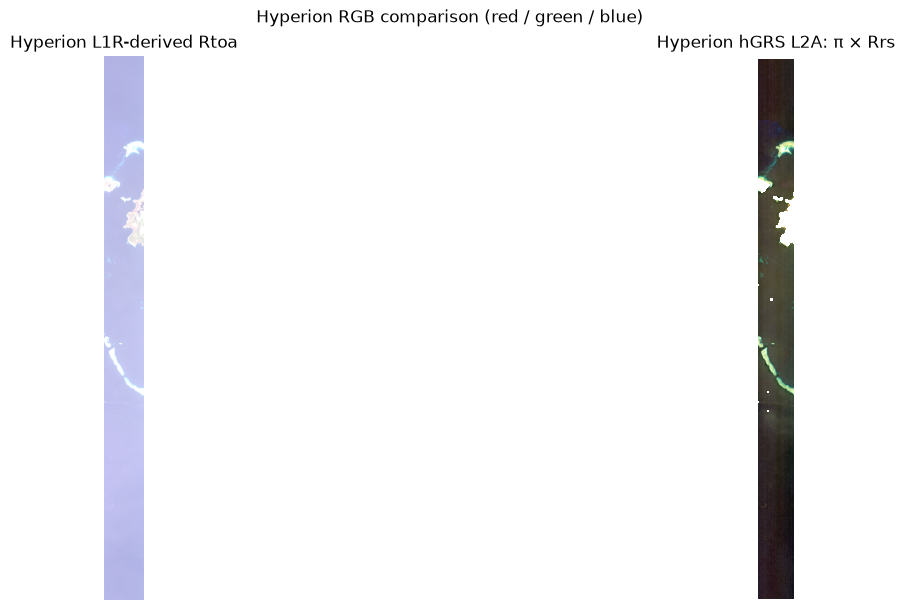

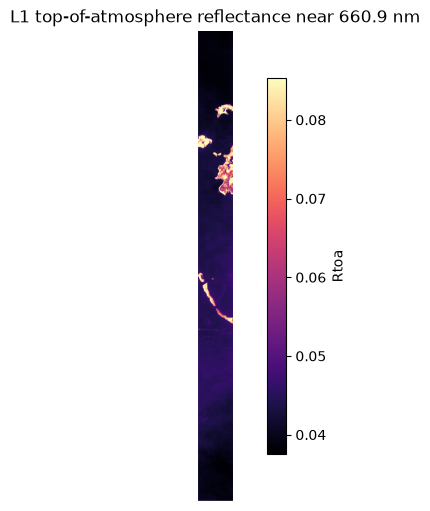

In [5]:
def rgb_from_l2(dataset, wavelengths=RGB_WAVELENGTHS_NM):
    return np.stack([
        np.asarray(dataset['Rrs'].sel(wl=w, method='nearest').values, dtype=np.float32) * np.pi
        for w in wavelengths
    ], axis=-1)


def shared_rgb_stretch(left, right, limits=None):
    combined = np.concatenate([left.reshape(-1, 3), right.reshape(-1, 3)], axis=0)
    if limits is None:
        limits = [(np.nanpercentile(combined[:, i], 2),
                   np.nanpercentile(combined[:, i], 98)) for i in range(3)]
    def stretch(array):
        result = np.empty_like(array, dtype=np.float32)
        for i, (low, high) in enumerate(limits):
            result[..., i] = np.clip((array[..., i] - low) / max(high - low, 1e-12), 0, 1)
        return np.power(result, 1 / 1.8)
    return stretch(left), stretch(right), limits


l2_rgb = rgb_from_l2(l2)
l1_view, l2_view, rgb_limits = shared_rgb_stretch(l1_rtoa_rgb, l2_rgb)
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
for ax, image, title in zip(axes, (l1_view, l2_view),
                            ('Hyperion L1R-derived Rtoa', 'Hyperion hGRS L2A: π × Rrs')):
    ax.imshow(image, origin='upper')
    ax.set_title(title)
    ax.set_axis_off()
fig.suptitle('Hyperion RGB comparison (red / green / blue)')
plt.show()

selected_rgb_channel = 0  # red channel, nearest 660.85 nm
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
image = ax.imshow(l1_rtoa_rgb[..., selected_rgb_channel], origin='upper', cmap='magma',
                  vmin=np.nanpercentile(l1_rtoa_rgb[..., selected_rgb_channel], 2),
                  vmax=np.nanpercentile(l1_rtoa_rgb[..., selected_rgb_channel], 98))
ax.set_title(f'L1 top-of-atmosphere reflectance near {l1_wavelengths[rgb_band_indices[0]]:.1f} nm')
ax.set_axis_off()
fig.colorbar(image, ax=ax, label='Rtoa', shrink=0.8)
plt.show()

## hGRS correction fields: `brdfg` and `tcwv`

Show full-resolution `brdfg_full` when available, plus the coarse retrieval `brdfg`. `tcwv` is retained on the retrieval grid (`yc`, `xc`) and shown in g/cm².

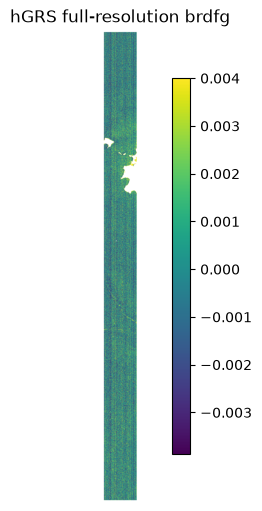

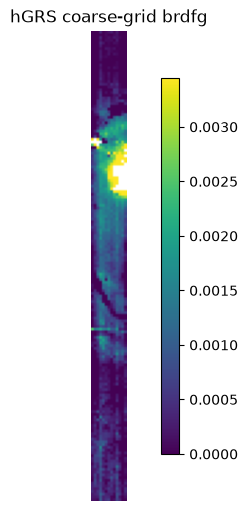

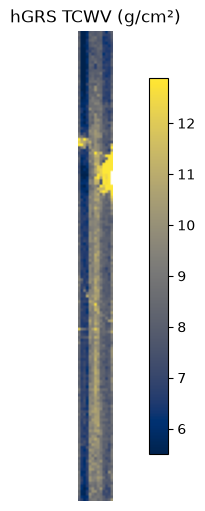

In [6]:
def show_map(da, title, cmap='viridis', limits=(2, 98)):
    values = np.asarray(da.values).squeeze()
    finite = values[np.isfinite(values)]
    if not finite.size:
        raise ValueError(f'{title} contains no finite values')
    low, high = np.percentile(finite, limits)
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    im = ax.imshow(values, origin='upper', cmap=cmap, vmin=low, vmax=high)
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.show()


if 'brdfg_full' in l2:
    show_map(l2['brdfg_full'], 'hGRS full-resolution brdfg', cmap='viridis')
show_map(l2['brdfg'], 'hGRS coarse-grid brdfg', cmap='viridis')
show_map(l2['tcwv'], 'hGRS TCWV (g/cm²)', cmap='cividis')

## Corrected spectrum compared with L1 `Rtoa`

Choose a pixel on the native Hyperion grid. The L1 spectrum is read from a single-pixel ENVI window, then converted to `Rtoa` with the same sensor response and solar geometry as above. The L2A spectrum is `π × Rrs` at the same row and column.

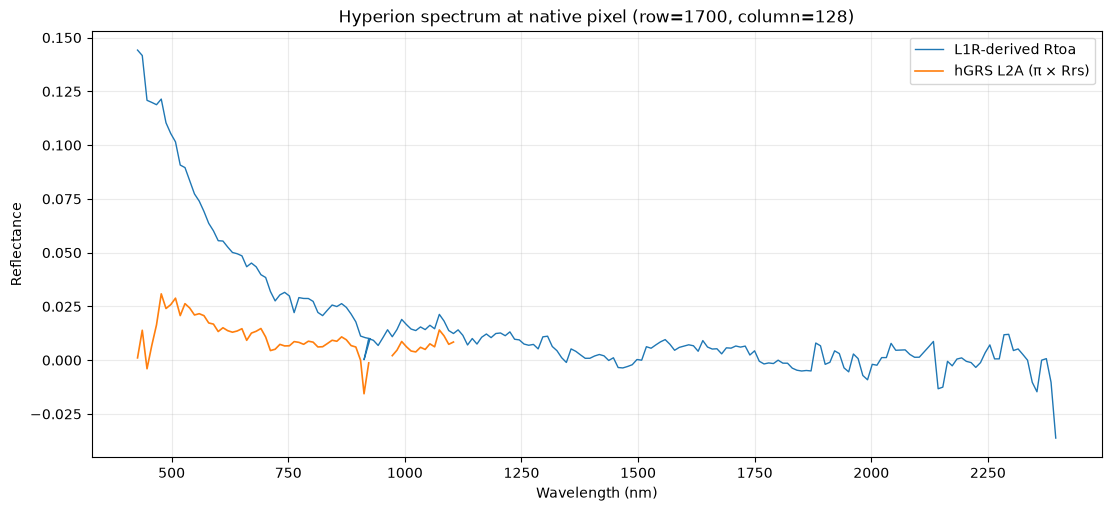

L2A source band numbers: [ 8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55
 77 78 79 83 84 85 86 87 88 89 90 91 92 93 94 95 96]


In [7]:
row, col = SPECTRUM_PIXEL
if not (0 <= row < l2.sizes['y'] and 0 <= col < l2.sizes['x']):
    raise IndexError(f'SPECTRUM_PIXEL {(row, col)} outside L2A raster')
with rasterio.open(L1_RADIANCE) as src:
    l1_radiance_spectrum = src.read(window=Window(col, row, 1, 1))[:, 0, 0].astype(np.float64)
l1_f0 = convolved_f0(l1_wavelengths, l1_fwhm)
l1_rtoa_spectrum = np.pi * l1_radiance_spectrum / (l1_f0 * mu0)
l2_rrs_spectrum = np.asarray(l2['Rrs'].isel(y=row, x=col).values, dtype=np.float64)

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(l1_wavelengths, l1_rtoa_spectrum, label='L1R-derived Rtoa', lw=1.0)
ax.plot(l2['wl'].values, np.pi * l2_rrs_spectrum,
        label='hGRS L2A (π × Rrs)', lw=1.2)
ax.set(xlabel='Wavelength (nm)', ylabel='Reflectance',
       title=f'Hyperion spectrum at native pixel (row={row}, column={col})')
ax.grid(alpha=0.25)
ax.legend()
plt.show()
print('L2A source band numbers:', l2['source_band_number'].values)

Close the lazy input datasets after plotting.

In [8]:
l2.close()
solar_ds.close()